<a href="https://colab.research.google.com/github/sayantan4u/Appium-Python-Android-Pytest_Project/blob/main/LangGraph/Solutions/AgentBot_LangGraph_01_02_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install langchain_core langchain_openai langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.9/84.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 496.3/496.3 kB 18.0 MB/s eta 0:00:00
  Attempting uninstall: langchain_core
    Found existing installation: langchain-core 1.2.8
    Uninstalling langchain-core-1.2.8:
      Successfully uninstalled langchain-core-1.2.8


In [2]:
!pip install python-dotenv

In [21]:
from typing import TypedDict, List
from langchain_core.messages import HumanMessage
from langchain_openai import AzureChatOpenAI
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv # used to store secret stuff like API keys or configuration values

In [32]:
from google.colab import userdata
import os
load_dotenv()
# Get the API key from environment variables
os.environ["AZURE_OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
#os.environ["AZURE_OPENAI_ENDPOINT"] = userdata.get('OPENAI_API_URL')
os.environ["AZURE_OPENAI_ENDPOINT"] = ("https://aicafe.hcl.com/AICafeService/api/v1/subscription/openai/"
    "deployments/gpt-4.1/chat/completions?api-version=2024-12-01-preview")
os.environ["OPENAI_API_VERSION"]="2024-12-01-preview"
class AgentState(TypedDict):
    messages: List[HumanMessage]

llm = AzureChatOpenAI(azure_deployment="gpt-4.1", temperature=0)

def process(state: AgentState) -> AgentState:
    response = llm.invoke(state["messages"])
    print(f"\nAI: {response.content}")
    return state

In [33]:
graph = StateGraph(AgentState)
graph.add_node("process", process)
graph.add_edge(START, "process")
graph.add_edge("process", END)
agent = graph.compile()

user_input = input("Enter: ")
while user_input != "exit":
    agent.invoke({"messages": [HumanMessage(content=user_input)]})
    user_input = input("Enter: ")

KeyboardInterrupt: Interrupted by user

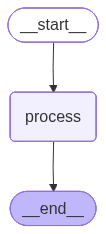

In [ ]:
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))